<a target="_blank" href="https://colab.research.google.com/github/cyneuro/ML_camp/blob/main/camp_logreg_microbit.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Logistic regression with micro:bit

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Read and preprocess the data

- Read the recorded dataset.
- Compute velocity and position from acceleration.

In [17]:
def process_data(df):
    df = df.copy()

    # Ensure numeric
    for c in ["time (seconds)", "x", "y", "z"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop bad rows
    df = df.dropna(subset=["time (seconds)", "x", "y", "z"])

    # Sort by time
    df = df.sort_values("time (seconds)").reset_index(drop=True)

    # Accel magnitude (useful feature)
    df["mag"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

    # Optional: simple rolling smooth (comment out if you don’t want it)
    # df["mag_smooth"] = df["mag"].rolling(window=5, min_periods=1).mean()

    return df

In [18]:
def parse_block(text):
    rows = []
    for line in text.strip().splitlines():
        t, x, y, z = line.split()
        rows.append([float(t), float(x), float(y), float(z)])
    return pd.DataFrame(rows, columns=["time (seconds)", "x", "y", "z"])

# paste your 4 blocks into these strings (exactly the rows)
block1 = """
0.00 12 -64 -1100
0.15 24 -128 -1084
0.31 32 -128 -1012
0.46 28 -128 -1016
0.61 32 -128 -1012
0.76 36 -136 -1024
0.91 24 -132 -992
1.07 32 -136 -1004
1.22 36 -140 -1016
1.37 28 -132 -1004
1.52 36 -132 -1008
1.67 40 -132 -1020
1.83 32 -132 -1004
1.98 36 -136 -996
2.13 32 -136 -1020
2.29 44 -140 -1012
2.44 40 -140 -1008
2.59 36 -136 -1012
2.74 28 -128 -1000
2.89 32 -124 -1012
3.05 40 -128 -1016
3.20 32 -132 -1012
3.35 36 -136 -1020
3.50 40 -132 -1012
3.65 32 -128 -1008
3.81 36 -136 -1012
3.96 32 -136 -1012
4.11 36 -136 -1008
4.26 32 -136 -1016
4.41 28 -136 -1004
4.57 32 -140 -1020
4.72 32 -140 -1012
4.87 40 -140 -1008
"""

block2 = """
0.00 -60 -112 -988
0.15 -712 1016 -1380
0.30 292 -300 -660
0.46 180 -336 -588
0.61 1392 -1880 -2040
0.76 -12 -164 -676
0.91 -572 728 -716
1.07 -852 1000 104
1.22 344 248 -128
1.37 -236 380 200
1.52 576 -392 -760
1.67 360 -452 -1100
1.83 1132 -424 -1568
1.98 2040 -2040 -1920
2.13 2040 -1312 -1992
2.28 2040 -2040 -2040
2.43 2040 -2040 -2040
2.59 2040 -1844 -1280
2.74 -1296 700 292
2.89 -2024 1408 -488
3.04 -2040 1544 -584
3.19 -2040 1516 -708
3.35 -2040 2040 1916
3.50 2040 -1484 -1556
3.65 2040 -1384 -1276
3.81 2040 432 -2040
3.96 2040 -1292 -2040
4.11 -1496 708 -12
4.26 -1612 68 -1176
4.41 -2040 964 -768
4.57 -1256 1748 1820
4.72 1980 -276 -2040
4.87 2040 -2040 -2040
"""

block3 = """
0.00 -8 -68 -1008
0.15 36 -128 -1012
0.31 28 -100 -1012
0.46 40 -112 -1008
0.61 36 -96 -1004
0.76 56 -104 -1016
0.92 40 -112 -1020
1.07 40 -108 -1012
1.22 52 -96 -1016
1.37 56 -112 -1016
1.52 48 -108 -1024
1.67 48 -104 -1016
1.83 56 -108 -1020
1.98 48 -96 -1016
2.13 52 -108 -1008
2.28 40 -100 -1028
2.43 44 -96 -1008
2.59 56 -108 -1020
2.74 52 -108 -1012
2.89 48 -104 -1012
3.04 40 -108 -1016
3.19 60 -104 -1028
3.35 52 -104 -1008
3.50 52 -104 -1020
3.65 52 -108 -1004
3.80 56 -104 -1016
3.95 56 -100 -1004
4.11 48 -104 -1008
4.26 52 -104 -1020
4.41 48 -104 -1008
4.56 48 -112 -1004
4.72 48 -100 -1016
4.87 44 -100 -1016
"""

block4 = """
0.00 32 -104 -1072
0.15 76 -148 -980
0.30 272 -236 -2040
0.46 -504 336 -224
0.61 -1516 660 -272
0.76 -1472 972 -112
0.91 -1604 1052 -584
1.06 -2040 1916 -1044
1.22 -2040 1708 -844
1.37 -2040 1576 -620
1.52 -556 388 -956
1.67 -1340 880 -600
1.83 -1452 752 -948
1.98 -1124 1348 -972
2.13 -1240 832 -388
2.28 -1172 768 -1356
2.44 -1640 936 -708
2.59 -960 752 -456
2.74 -2040 1908 320
2.89 -1008 804 268
3.04 -1304 872 -408
3.20 2040 -1032 -2040
3.35 2040 -524 -252
3.50 2040 1120 2040
3.65 880 -536 176
3.80 1356 -872 -896
3.96 -380 4 -832
4.11 -744 276 -960
4.26 -1088 880 -256
4.41 -1408 1644 -1092
4.57 2040 -1556 520
4.72 2040 -1352 -2040
4.87 1184 -756 -1192
"""


dfs = [parse_block(block1), parse_block(block2), parse_block(block3), parse_block(block4)]

# make time continuous (important because each block restarts at 0.00)
offset = 0.0
for df in dfs:
    df["time (seconds)"] = df["time (seconds)"] + offset
    offset = df["time (seconds)"].max() + 0.15

data = pd.concat(dfs, ignore_index=True)
data = process_data(data)
data.head()

,time (seconds),x,y,z,mag
0,0.00,12.0,-64.0,-1100.0,1101.925587
1,0.15,24.0,-128.0,-1084.0,1091.794853
2,0.31,32.0,-128.0,-1012.0,1020.564550
3,0.46,28.0,-128.0,-1016.0,1024.413979
4,0.61,32.0,-128.0,-1012.0,1020.564550


In [19]:
def parse_segment(seg_text, seg_id):
    rows = []
    for line in seg_text.strip().splitlines():
        parts = line.split()
        if len(parts) != 4:
            continue
        t, x, y, z = map(float, parts)
        rows.append((t, x, y, z, seg_id))
    return pd.DataFrame(rows, columns=["time (seconds)", "x", "y", "z", "segment"])

dfs = [
    parse_segment(block1, 1),  # rest
    parse_segment(block2, 2),  # shake
    parse_segment(block3, 3),  # rest
    parse_segment(block4, 4),  # shake
]


# Make time continuous by offsetting each segment
offset = 0.0
for df in dfs:
    df["time (seconds)"] = df["time (seconds)"] + offset
    offset = df["time (seconds)"].max() + 0.15  # approx next tick gap

data_raw = pd.concat(dfs, ignore_index=True)
data_raw.head(), data_raw.tail()


(   time (seconds)     x      y       z  segment
 0            0.00  12.0  -64.0 -1100.0        1
 1            0.15  24.0 -128.0 -1084.0        1
 2            0.31  32.0 -128.0 -1012.0        1
 3            0.46  28.0 -128.0 -1016.0        1
 4            0.61  32.0 -128.0 -1012.0        1,
      time (seconds)       x       y       z  segment
 127           19.32 -1088.0   880.0  -256.0        4
 128           19.47 -1408.0  1644.0 -1092.0        4
 129           19.63  2040.0 -1556.0   520.0        4
 130           19.78  2040.0 -1352.0 -2040.0        4
 131           19.93  1184.0  -756.0 -1192.0        4)

In [20]:
# Convert milligravities to m/s2
MG_TO_MS2 = 0.00980665

def process_data(data):
    # Clean the columns
    orig_columns = ["time (seconds)", "x", "y", "z"]
    new_columns = ["t", "ax", "ay", "az"]
    data = data[orig_columns]
    data.columns = new_columns

    # Clean NaNs
    data = data.dropna()

    # Convert to m/s2
    for acc in ['ax', 'ay', 'az']:
        data[acc] = data[acc] * MG_TO_MS2

    # Replace outliers with the median
    for acc in ['ax', 'ay', 'az']:
        acc_raw = data[acc].copy()
        acc_raw[np.abs(acc_raw / np.median(acc_raw)) > 1.5] = np.median(acc_raw)
        data[acc] = acc_raw

    # Compute velocity
    data['vx'] = cumulative_trapezoid(data['ax'], data['t'], initial = 0)
    data['vy'] = cumulative_trapezoid(data['ay'], data['t'], initial = 0)
    data['vz'] = cumulative_trapezoid(data['az'], data['t'], initial = 0)

    # Compute position
    data['x'] = cumulative_trapezoid(data['vx'], data['t'], initial = 0)
    data['y'] = cumulative_trapezoid(data['vy'], data['t'], initial = 0)
    data['z'] = cumulative_trapezoid(data['vz'], data['t'], initial = 0)

    return data

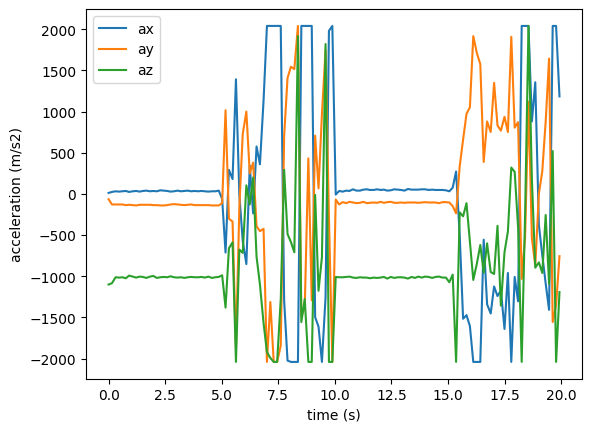

In [21]:
data = data.rename(columns={
    "time (seconds)": "t",
    "x": "ax",
    "y": "ay",
    "z": "az"
})

for acc in ['ax', 'ay', 'az']:
    plt.plot(data['t'], data[acc], label = acc)
plt.xlabel("time (s)")
plt.ylabel("acceleration (m/s2)")
plt.legend()

## 2. Split into train and test samples.
- Train: the first shake.
- Test: the second shake.

In [22]:
#TODO: adjust to your values

train_rest  = (0.5, 4.2)    # inside block 1
train_shake = (5.2, 9.5)    # inside block 2 (after offset)

test_rest   = (10.2, 14.5)  # inside block 3
test_shake  = (15.2, 19.5)  # inside block 4


In [23]:
def construct_Xy(data, window_rest, window_shake):
    X = pd.concat((
        data.loc[(data['t'] >= window_rest[0]) & (data['t'] <= window_rest[1]), ['t', 'ax', 'ay', 'az']],
        data.loc[(data['t'] >= window_shake[0]) & (data['t'] <= window_shake[1]), ['t', 'ax', 'ay', 'az']],
    ))
    y = np.ones(len(X))
    y[(X['t'] >= window_rest[0]) & (X['t'] <= window_rest[1])] = 0

    return X, y

In [24]:
X_train, y_train = construct_Xy(data, train_rest, train_shake)
X_test, y_test = construct_Xy(data, test_rest, test_shake)

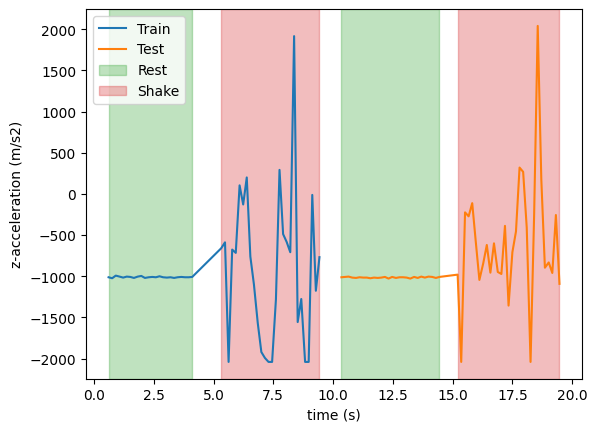

In [25]:
plt.plot(X_train['t'], X_train["az"], label = "Train")
plt.plot(X_test['t'], X_test["az"], label = "Test")

label_set = False
for X, y in [(X_train, y_train), (X_test, y_test)]:
    for y_value, y_label in enumerate(["Rest", "Shake"]):
        plt.axvspan(
            X['t'].to_numpy()[np.where(y == y_value)[0][0]],
            X['t'].to_numpy()[np.where(y == y_value)[0][-1]],
            alpha = 0.3,
            color = "tab:green" if y_value == 0 else "tab:red",
            label = y_label if not label_set else None
            )
    label_set = True

plt.xlabel("time (s)")
plt.ylabel("z-acceleration (m/s2)")
plt.legend()

## 3. Train a logistic regression model

Compare 2 models.

**Model 1.**

$$
\hat{p} = \sigma(b_0 + b_t \times t + b_x \times a_x + b_y \times a_y + b_z \times a_z)
$$

**Model 2.**

$$
\hat{p} = \sigma(b_0 + b_x \times a_x + b_y \times a_y + b_z \times a_z)
$$

In [26]:
model1 = LogisticRegression()
model1.fit(X_train[["t", "ax", "ay", "az"]], y_train)

model2 = LogisticRegression()
model2.fit(X_train[["ax", "ay", "az"]], y_train)

LogisticRegression()

In [27]:
print("ACCURACY")
print("--------")
print("Model\tTrain\tTest")
for model_id, (model, features) in enumerate((
    (model1, ["t", "ax", "ay", "az"]),
    (model2, ["ax", "ay", "az"])
    )):
    train_acc = round(accuracy_score(y_train, model.predict(X_train[features])), 2)
    test_acc = round(accuracy_score(y_test, model.predict(X_test[features])), 2)
    print(f"M{model_id}\t{train_acc}\t{test_acc}")

ACCURACY
--------
Model	Train	Test
M0	1.0	0.51
M1	0.42	0.21


In [28]:
model1.predict(X_test[["t", "ax", "ay", "az"]])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1.])

In [29]:
model2.predict(X_test[["ax", "ay", "az"]])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 0., 0., 1., 0.])

### Question

Explain the observed difference between predictions of the two models.

**Hint: compare the decision lines.**

In [30]:
print(f"Model1: intercept = {model1.intercept_}, coef = {model1.coef_}")
print(f"Model2: intercept = {model2.intercept_}, coef = {model2.coef_}")

Model1: intercept = [-6.49560046], coef = [[ 1.93813694e+00  9.78162604e-04 -1.18859932e-03  3.13019337e-03]]
Model2: intercept = [0.96791973], coef = [[5.99838426e-04 9.12765103e-05 9.09257109e-04]]


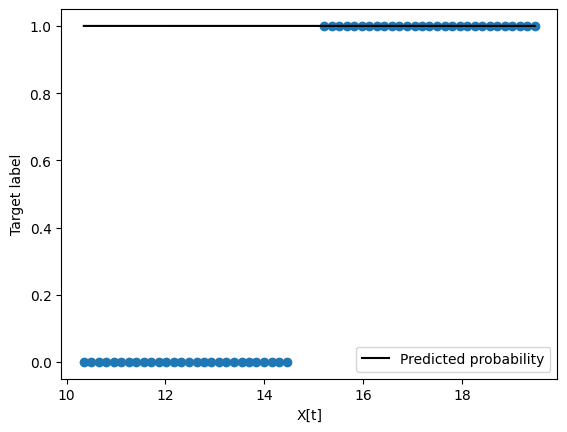

In [31]:
plt.scatter(X_test["t"], y_test)
plt.xlabel("X[t]")
plt.ylabel("Target label")

plt.plot(X_test["t"], model1.predict_proba(X_test[["t", "ax", "ay", "az"]])[:, 1], label = "Predicted probability", c = "black")
plt.legend()

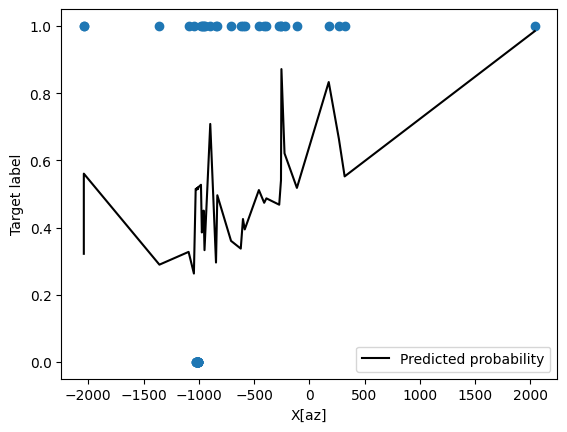

In [32]:
plt.scatter(X_test["az"], y_test)
plt.xlabel("X[az]")
plt.ylabel("Target label")

plt.plot(X_test.sort_values("az")["az"], model2.predict_proba(X_test.sort_values("az")[["ax", "ay", "az"]])[:, 1], label = "Predicted probability", c = "black")
plt.legend()